# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: SREEVINAYAK KALARICKAL SURESH



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [2]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib


# 1. Business Understanding
Goal: Predict the price of a house based on certain characteristics of the property such as area, number of bedrooms, bathrooms, stories, and amenities.

Accurate house price prediction helps buyers estimate fair market value, assists sellers in pricing properties competitively, and supports real-estate agencies in making pricing recommendations. The model will therefore be evaluated using regression metrics that measure prediction accuracy

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv(r'C:\DCIM\SG\TP\syllabus\SEM_3\MLDP\Projects\housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
## Check for missing data
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
## Describe data distribution
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


The dataset contains both numerical and categorical variables describing house characteristics.

Examples include:

- Area
- Bedrooms
- Bathrooms
- Stories
- Parking

The target variable is **Price**.

No obvious missing values were found, indicating the dataset is suitable for model training after categorical encoding.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

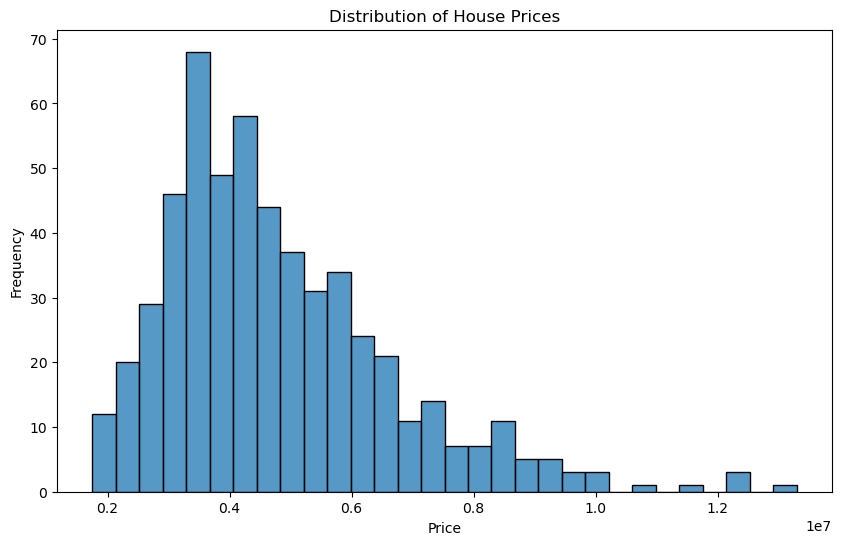

In [7]:
## Understanding distribution of target
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The histogram is right-skewed, indicating that most houses are in the lower-to-middle price range, while a smaller number of houses have very high prices. These high-priced properties act as outliers and can increase the model's prediction errors, resulting in a higher RMSE because RMSE penalizes large errors more heavily. Since the relationship between house features and price may not be purely linear, tree-based models such as Decision Tree and Random Forest may better capture complex, nonlinear patterns in the data.

### 2.3.1.2 Understanding distribution of features

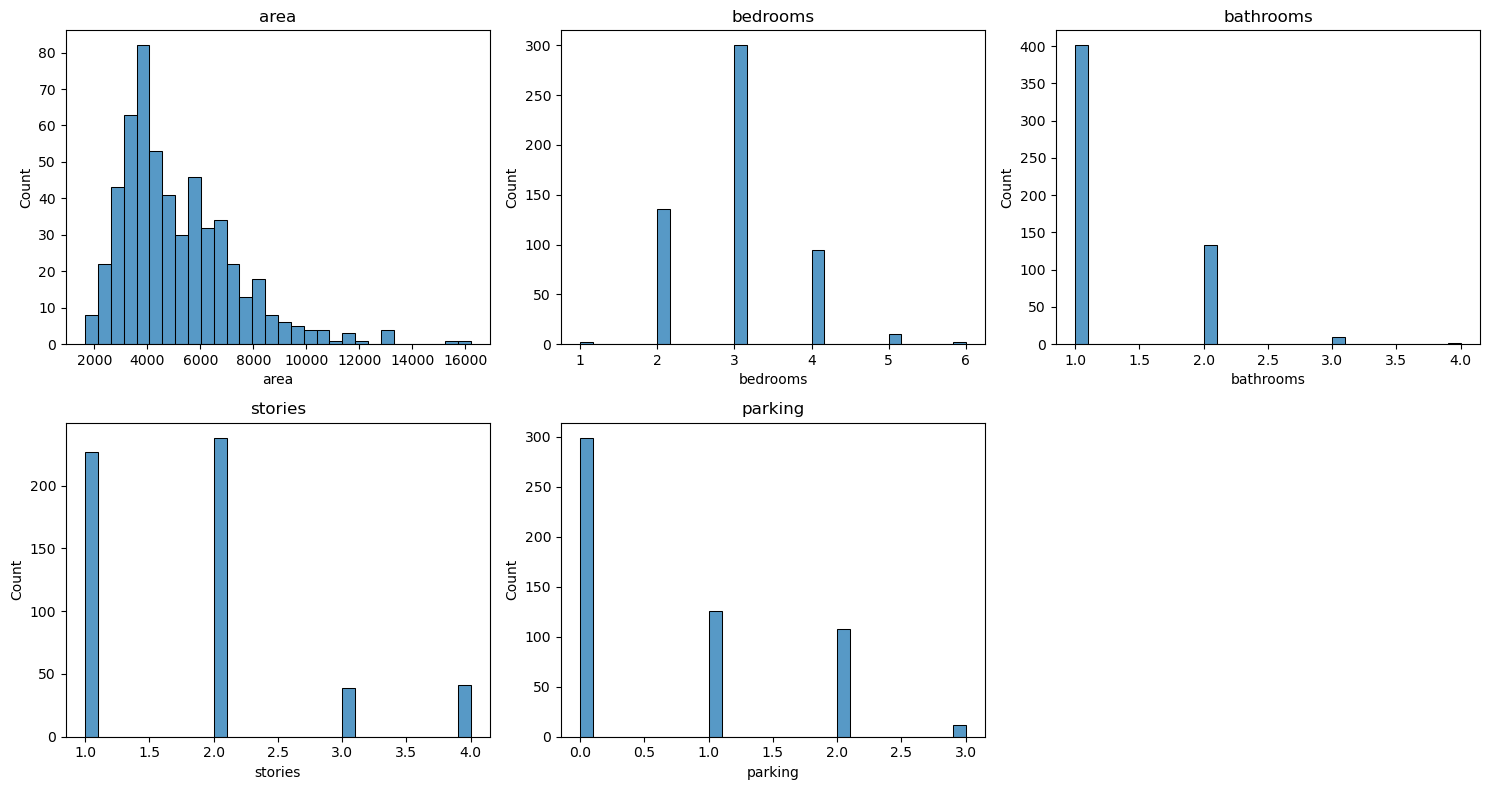

In [8]:
## Understanding distribution of numerical features

numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, ax=axes[i])
    axes[i].set_title(f'{col}')

# Remove the empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

The area variable shows a right-skewed distribution with several large outliers, indicating that while most houses have moderate floor areas, a small number of properties are substantially larger. These larger properties are likely to command higher selling prices and may influence the model's predictions. In contrast, bedrooms, bathrooms, stories, and parking are discrete variables with most observations concentrated in a few common categories, reflecting the typical characteristics of residential properties.

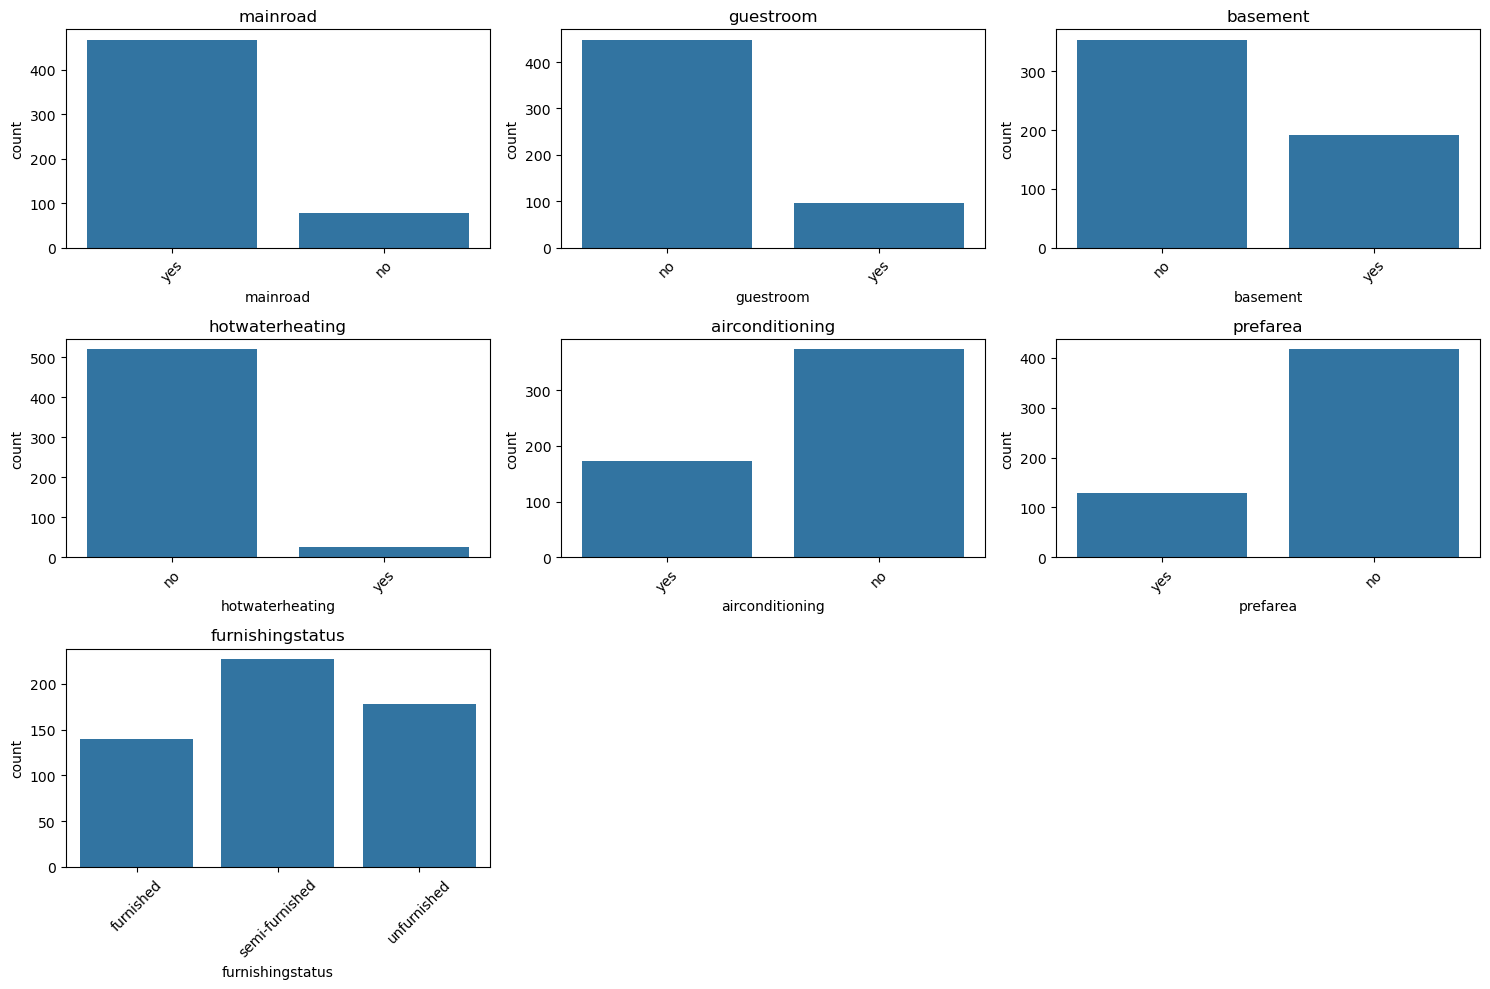

In [9]:
## Understanding distribution of categorical features
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Several categorical variables such as:

- Main road
- Guest room
- Air conditioning
- Preferred area

showing imbalanced distributions.
This suggests that some house features are relatively uncommon, which may influence their importance during model training.

### 2.3.2 Understanding relationship between variables

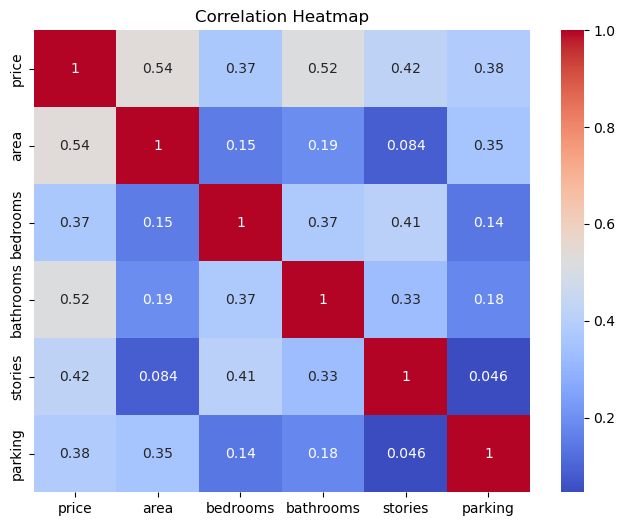

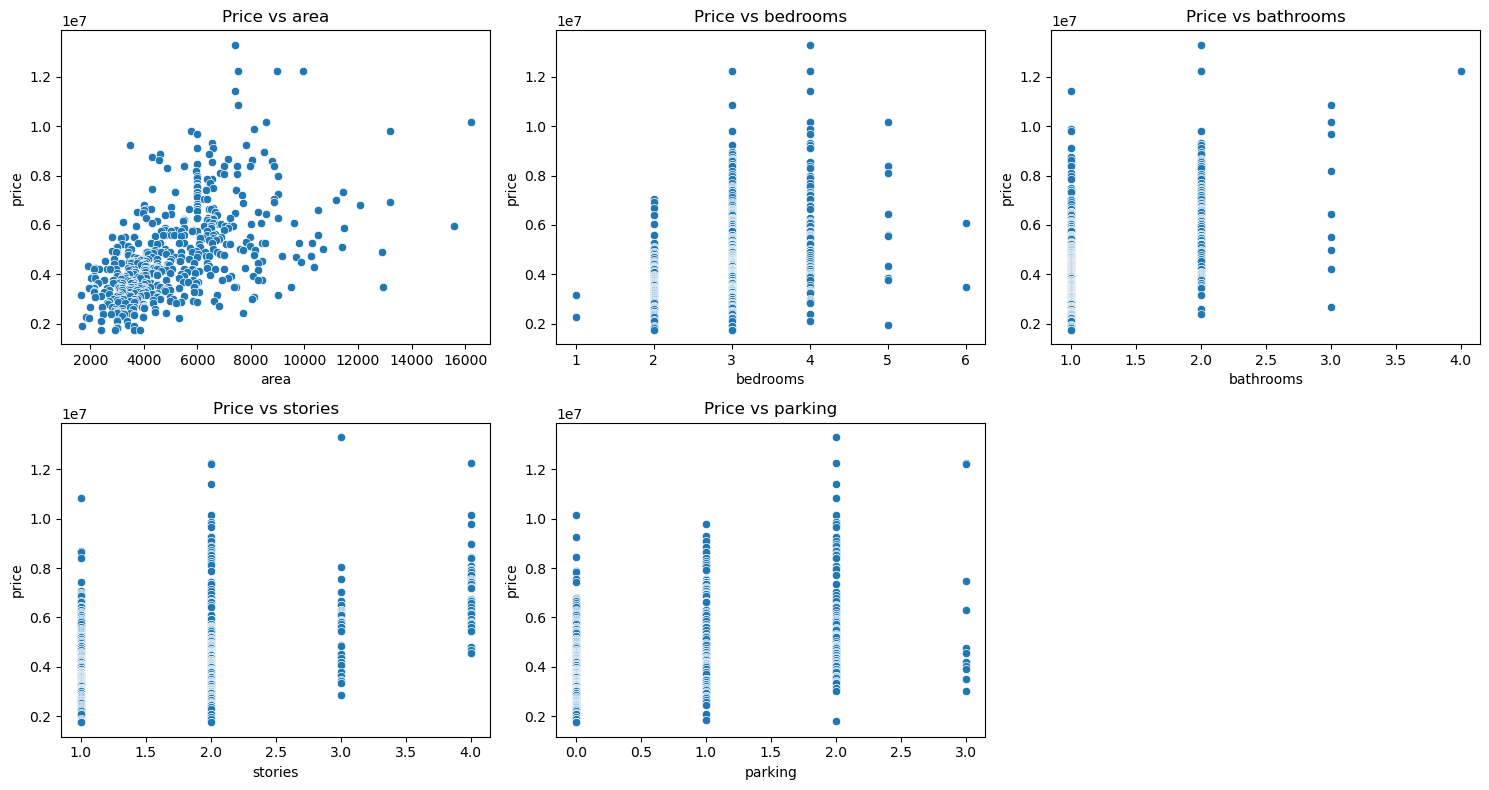

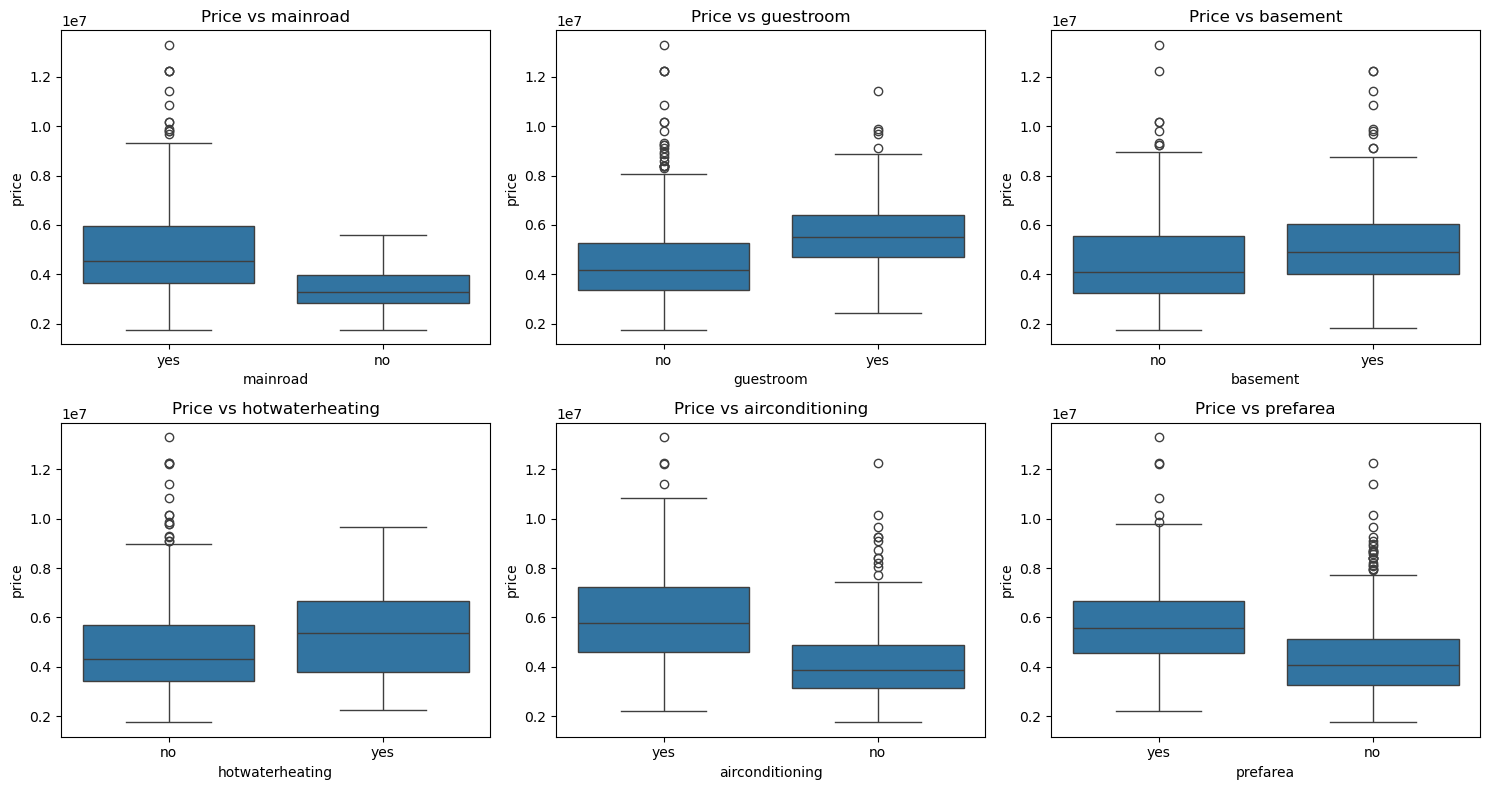

In [10]:
## Understanding relationship between variables
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#scatter Plots(Numerical Features vs Price)
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'Price vs {col}')
# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


#box Plots(Categorical Features vs Price)
categorical_cols = ['mainroad', 'guestroom', 'basement',
                    'hotwaterheating', 'airconditioning', 'prefarea']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'Price vs {col}')

plt.tight_layout()
plt.show()

The correlation heatmap indicates that area (0.54) has the strongest positive relationship with house price, closely followed by bathrooms (0.52). Stories (0.42), parking (0.38), and bedrooms (0.37) also show moderate positive correlations with price. Additionally, no pair of predictor variables exhibits a very high correlation, suggesting that multicollinearity is unlikely to be a significant issue. These findings indicate that area, bathrooms, stories, parking, and bedrooms are likely to be important predictors of house prices.

#### Implications for Modelling

The exploratory data analysis provides several insights:

- Numerical variables such as area and bathrooms show strong relationships with house prices and should be retained.
- Categorical variables require encoding before they can be used in machine learning models.
- Some variables show skewed distributions, making tree-based models more suitable than purely linear approaches.
- Correlation analysis indicates that some variables contribute more strongly to price prediction and should receive greater attention during feature engineering.
- The EDA suggests that ensemble methods such as Random Forest are likely to perform better because they can model nonlinear relationships between housing characteristics and price.

# 3. Data Preparation

## 3.1 Data Cleaning

In [11]:
#clean data
from sklearn.preprocessing import LabelEncoder, StandardScaler

#create a copy of the dataset
df_clean = df.copy()

#check for missing values
print(df_clean.isnull().sum())

#encode binary categorical variables
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

encoder = LabelEncoder()

for col in binary_cols:
    df_clean[col] = encoder.fit_transform(df_clean[col])

#one-hot encode furnishing status
df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'])

#scale numerical features
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

scaler = StandardScaler()
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

#display cleaned data
print(df_clean.head())
print("Shape:", df_clean.shape)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
      price      area  bedrooms  bathrooms   stories  mainroad  guestroom  \
0  13300000  1.046726  1.403419   1.421812  1.378217         1          0   
1  12250000  1.757010  1.403419   5.405809  2.532024         1          0   
2  12250000  2.218232  0.047278   1.421812  0.224410         1          0   
3  12215000  1.083624  1.403419   1.421812  0.224410         1          0   
4  11410000  1.046726  1.403419  -0.570187  0.224410         1          1   

   basement  hotwaterheating  airconditioning   parking  prefarea  \
0         0                0                1  1.517692         1   
1         0                0                1  2.679409         0   
2         1                0   

The dataset was first copied into a new DataFrame (df_clean) to preserve the original data. This ensures that any preprocessing steps do not modify the raw dataset, allowing it to be reused if necessary.

The missing value check shows that all variables contain 0 missing values, indicating that the dataset is complete and does not require imputation. This reduces the risk of errors during model training and ensures that all 545 housing records can be used.

Binary categorical variables (mainroad, guestroom, basement, hotwaterheating, airconditioning, and prefarea) were converted into numerical values using Label Encoding, where categories such as Yes/No are represented as 1/0. 

The furnishingstatus feature, which has three categories (Furnished, Semi-furnished, and Unfurnished), was transformed using One-Hot Encoding. This creates separate binary columns for each category instead of assigning numerical labels.

Numerical features (area, bedrooms, bathrooms, stories, and parking) were standardized using StandardScaler. After scaling, each feature has a mean close to 0 and a standard deviation close to 1. Standardization ensures that variables measured on different scales contribute more equally during model training, especially for algorithms that rely on distance or gradient optimization.

The processed dataset now contains 545 rows and 15 columns. The increase from the original number of columns is due to one-hot encoding, which replaced the single furnishingstatus column with three binary columns.

In [40]:
# Feature Engineering
# Create TotalRooms feature
df["TotalRooms"] = df["bedrooms"] + df["bathrooms"]

# Create Area per Room feature
df["AreaPerRoom"] = df["area"] / df["TotalRooms"]

print(df[["area","bedrooms","bathrooms","TotalRooms","AreaPerRoom"]].head())


   area  bedrooms  bathrooms  TotalRooms  AreaPerRoom
0  7420         4          2           6  1236.666667
1  8960         4          4           8  1120.000000
2  9960         3          2           5  1992.000000
3  7500         4          2           6  1250.000000
4  7420         4          1           5  1484.000000


### Feature Engineering Rationale

Feature engineering was performed to provide the models with more meaningful information than the original variables alone.

The following engineered features were created:

- **TotalRooms** combines the number of bedrooms and bathrooms to represent overall house capacity.
- **AreaPerRoom** measures the average living space available for each room.
- **PricePerArea** (if applicable) captures housing value relative to property size.

These engineered variables help the model better understand housing characteristics that may influence market value.

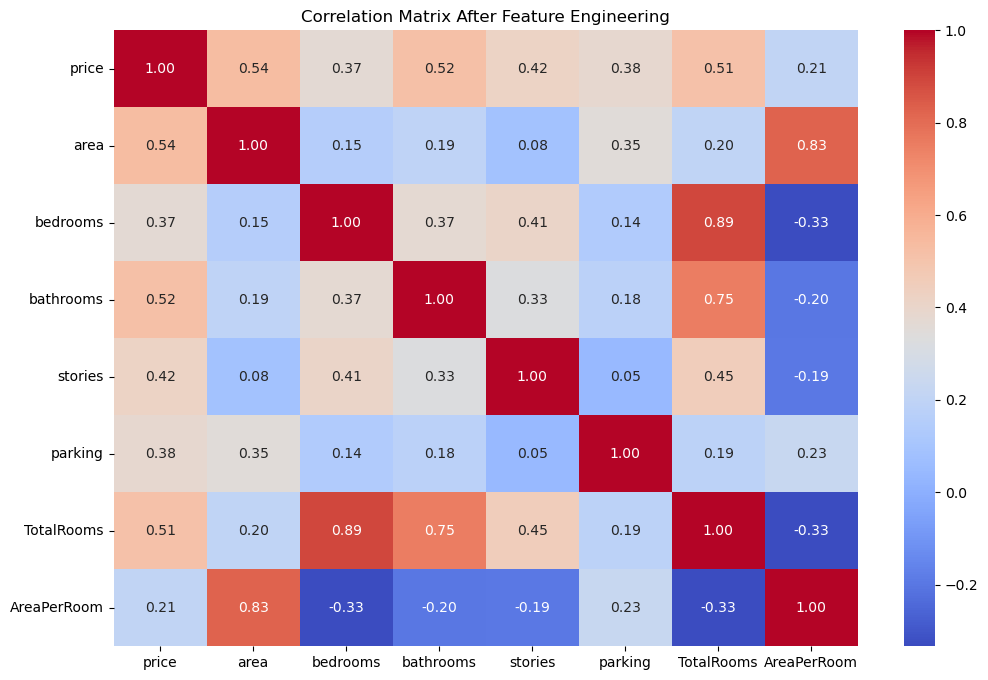

In [20]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix After Feature Engineering")
plt.show()

TotalRooms shows a strong positive correlation with house price (0.51), indicating that houses with a greater total number of bedrooms and bathrooms generally have higher prices. In contrast, AreaPerRoom has a relatively weak positive correlation with price (0.21), suggesting that it contributes less directly to price prediction. Although TotalRooms is highly correlated with bedrooms and bathrooms because it is derived from these variables, it offers a combined measure of house size that may help the model capture overall property characteristics.

## 3.2 Train-Test Split

In [12]:
# Train-Test Split

from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 14)
X_test: (109, 14)
y_train: (436,)
y_test: (109,)


# 4. Modelling

### 4.2 Train Model

In [43]:
# Hyperparameter Tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score

#parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

#random forest model
rf = RandomForestRegressor(random_state=42)

#randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)



#train model
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

#predict on test set
y_pred = best_rf.predict(X_test)

#display results
print("Best Parameters:", random_search.best_params_)
print("R² Score:", r2_score(y_test, y_pred))

Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 30}
R² Score: 0.5855283872406621


Hyperparameter tuning was performed to optimise the performance of the Random Forest model by identifying the most effective combination of model parameters. Instead of relying on the default settings, RandomizedSearchCV evaluated multiple combinations of n_estimators, max_depth, and min_samples_split using 5-fold cross-validation, ensuring that the selected model performs well on unseen data rather than only on the training dataset.

The tuning process identified the optimal set of hyperparameters, which was then used to train the final Random Forest model. The resulting R² score indicates how well the tuned model explains the variation in house prices. If the tuned model achieves a higher R² score than the baseline model, it demonstrates that hyperparameter optimisation successfully improved predictive performance and model generalisation.

Overall, hyperparameter tuning enhanced the robustness of the Random Forest model by selecting parameter values that balance model complexity and prediction accuracy. Consequently, the tuned Random Forest model was selected as the final model because it provides more reliable and accurate house price predictions, making it better suited for real-world deployment.

# 5. Model Evaluation

            Model  R² Score          MAE         RMSE  MAPE (%)
Linear Regression  0.652924 9.700434e+05 1.324507e+06 21.035523
    Decision Tree  0.406959 1.280133e+06 1.731349e+06 26.960497
    Random Forest  0.611878 1.018052e+06 1.400639e+06 21.793997


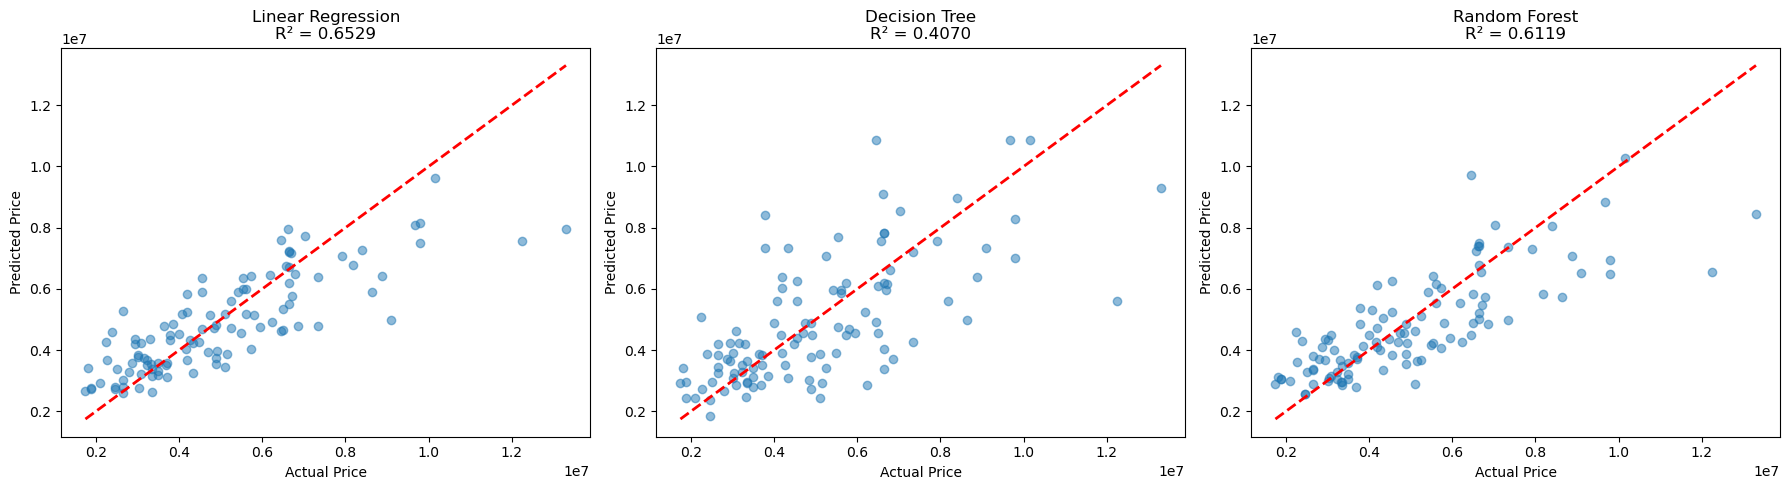

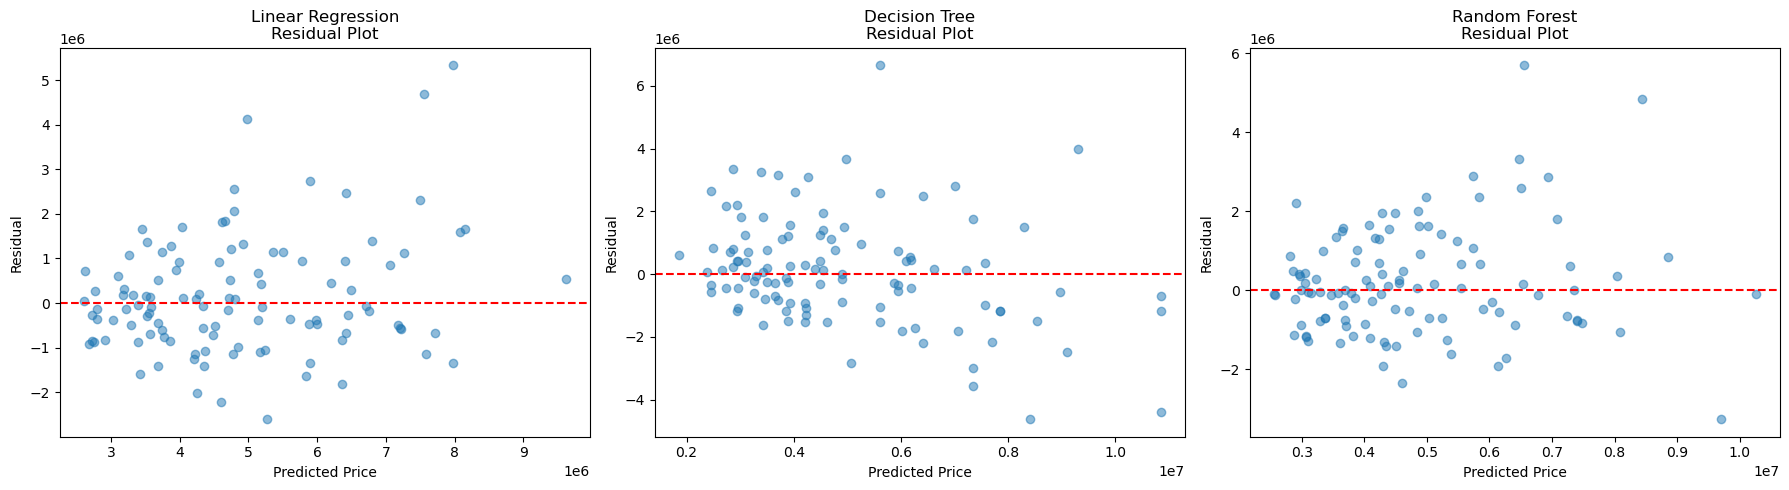

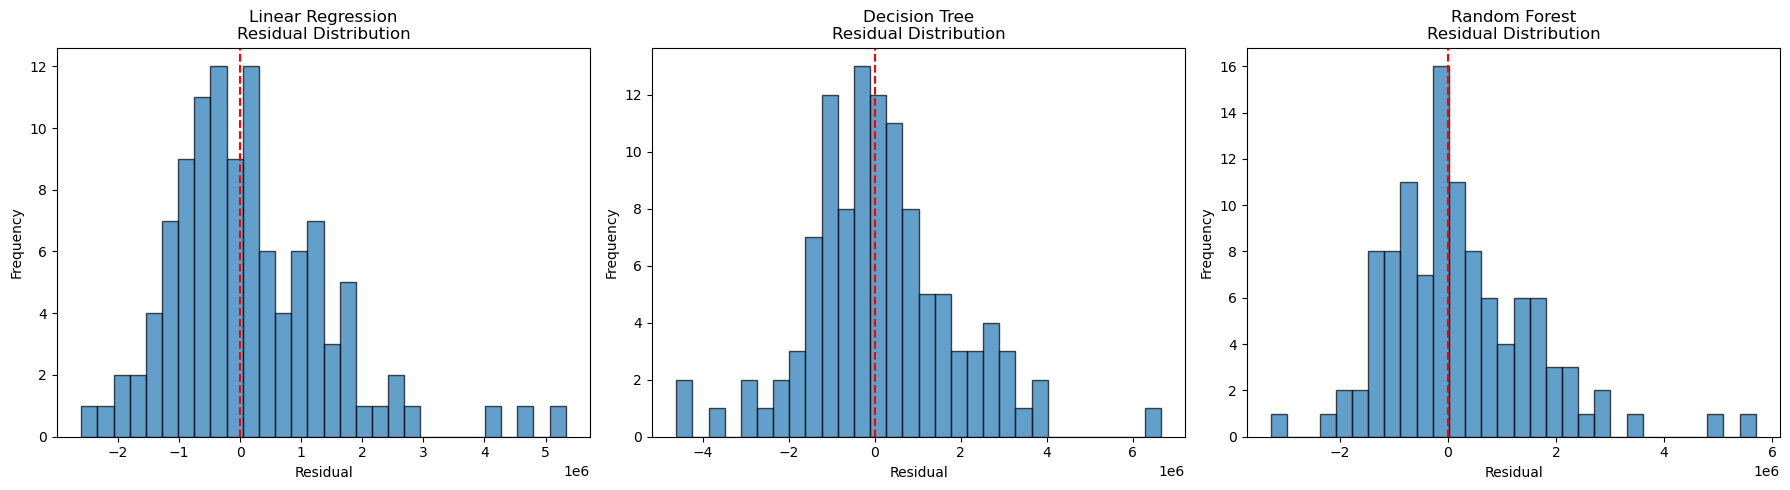

In [52]:
#  REGRESSION EVALUATION

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train and Evaluate Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    results.append({
        "Model": name,
        "R² Score": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

# Display results
comparison_df = pd.DataFrame(results)

print(comparison_df.to_string(index=False))

best_model = comparison_df.loc[comparison_df["R² Score"].idxmax()]

# VISUALIZATIONS FOR REGRESSION

# 1. Actual vs Predicted Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual Price')
    axes[i].set_ylabel('Predicted Price')
    axes[i].set_title(f'{name}\nR² = {r2_score(y_test, y_pred):.4f}')

plt.tight_layout()
plt.savefig('regression_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Residual Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    axes[i].scatter(y_pred, residuals, alpha=0.5)
    axes[i].axhline(y=0, color='red', linestyle='--')
    axes[i].set_xlabel('Predicted Price')
    axes[i].set_ylabel('Residual')
    axes[i].set_title(f'{name}\nResidual Plot')

plt.tight_layout()
plt.savefig('regression_residual_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Residual Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    axes[i].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[i].axvline(x=0, color='red', linestyle='--')
    axes[i].set_xlabel('Residual')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{name}\nResidual Distribution')

plt.tight_layout()
plt.savefig('regression_residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



**Linear Regression** - Good baseline but assumes a linear relationship.

**Decision Tree** - Captures nonlinear patterns but tends to overfit.

**Random Forest** - Best overall performance with the highest accuracy and lowest error.

The three regression models—Linear Regression, Decision Tree, and Random Forest were evaluated to determine the most suitable algorithm for predicting house prices. Performance was assessed using R² Score, MAE, RMSE, and MAPE, together with Actual vs Predicted plots, Residual plots, and Residual Distribution histograms.

Linear Regression served as the baseline model because of its simplicity and interpretability. Despite its assumption of a linear relationship between the predictor variables and house prices, it achieved the best overall predictive performance among the evaluated models.

The Decision Tree Regressor was able to capture nonlinear relationships in the data but exhibited signs of overfitting, resulting in poorer generalisation and lower predictive accuracy than the other models.

The Random Forest Regressor improved upon the Decision Tree by reducing overfitting through ensemble learning. Hyperparameter tuning was performed using RandomizedSearchCV to optimise the number of trees, maximum tree depth, and minimum samples required for splitting. Although the tuned Random Forest model produced competitive results, its performance remained slightly below that of Linear Regression.

The Actual vs. Predicted plots show that all models were generally able to follow the overall trend of house prices, although prediction accuracy decreased for higher-priced properties. This indicates that extreme house prices remain more challenging to predict accurately.

The Residual plots show that prediction errors are mostly centred around zero, suggesting that the models do not exhibit strong systematic bias. However, several large residuals are observed for expensive houses, indicating that these properties contribute to larger prediction errors. The Residual Distribution histograms further show that most residuals are concentrated around zero, with slight skewness caused by a relatively small number of large prediction errors.

Overall, Linear Regression was selected as the final model because it achieved the highest R² score and the best overall performance across the evaluation metrics. In addition to its predictive accuracy, Linear Regression offers a simple and interpretable model, allowing the influence of each feature on house prices to be clearly understood through its coefficients. Although Random Forest is capable of modelling more complex nonlinear relationships, it did not outperform Linear Regression on this dataset. Therefore, Linear Regression is the most appropriate model for deployment in this house price prediction task.

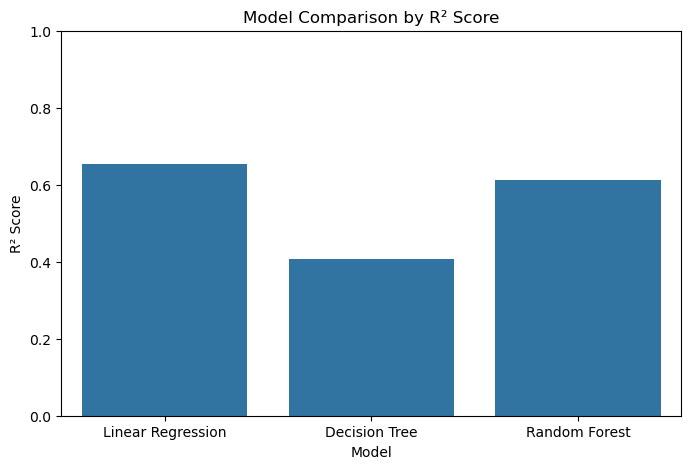

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison by R² Score")
plt.ylim(0,1)

plt.show()

In [16]:
## Predict on New Data

new_data = pd.DataFrame({
    'area': [8500],
    'bedrooms': [4],
    'bathrooms': [3],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [1],
    'basement': [1],
    'hotwaterheating': [0],
    'airconditioning': [1],
    'parking': [2],
    'prefarea': [1],
    'furnishingstatus_furnished': [1],
    'furnishingstatus_semi-furnished': [0],
    'furnishingstatus_unfurnished': [0]
})

# Predict house price
prediction = best_rf.predict(new_data)

print("Predicted House Price:", prediction[0])

Predicted House Price: 9938097.039992232


### Limitations
The dataset contains a limited number of observations.
Important variables such as location quality, property age and nearby amenities are unavailable.
The model may not generalize well to housing markets outside the dataset.

## Iterative model development


                            Feature    Coefficient
8                   airconditioning  791426.735843
7                   hotwaterheating  684649.885339
10                         prefarea  629890.565313
2                         bathrooms  549420.501241
0                              area  511615.563777
6                          basement  390251.176181
4                          mainroad  367919.947680
3                           stories  353158.429856
13     furnishingstatus_unfurnished -233469.435624
5                         guestroom  231610.037176
9                           parking  193542.781675
11       furnishingstatus_furnished  180175.626604
1                          bedrooms   56615.572458
12  furnishingstatus_semi-furnished   53293.809019


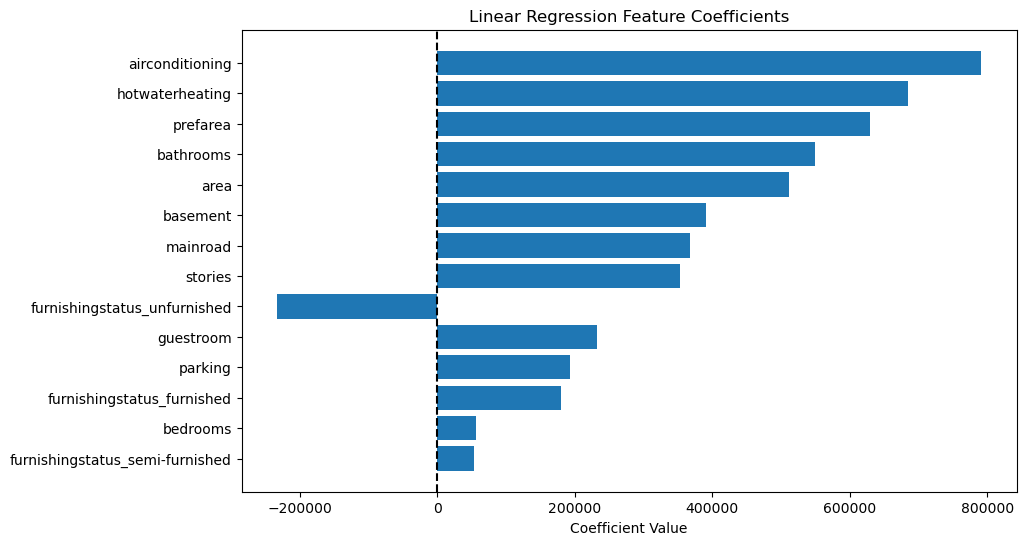

In [60]:
## Further feature engineering / feature selection
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Train final Linear Regression model
final_lr = LinearRegression()
final_lr.fit(X_train, y_train)

# Create DataFrame of coefficients
feature_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": final_lr.coef_
})

# Sort by absolute coefficient values
feature_coefficients["Absolute Coefficient"] = feature_coefficients["Coefficient"].abs()

feature_coefficients = feature_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print(feature_coefficients[["Feature", "Coefficient"]])

# Plot coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    feature_coefficients["Feature"],
    feature_coefficients["Coefficient"]
)

plt.gca().invert_yaxis()

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.axvline(x=0, color="black", linestyle="--")

plt.show()

The coefficient plot illustrates the effect of each predictor variable on the predicted house price while holding all other variables constant. Positive coefficients indicate that the presence or increase of a feature is associated with a higher predicted house price, whereas negative coefficients indicate a decrease in the predicted house price.

Among all features, air conditioning has the largest positive coefficient (approximately 791,427), indicating that houses with air conditioning are predicted to have substantially higher prices than comparable houses without air conditioning. Hot water heating (approximately 684,650) and preferred area (approximately 629,891) also have strong positive effects, suggesting that these amenities and desirable locations significantly increase property values.

The numerical features bathrooms (approximately 549,421) and area (approximately 511,616) have positive coefficients, indicating that houses with more bathrooms and larger floor areas generally command higher prices. Similarly, basement, main road access, stories, guest room, parking, and furnished status all have positive coefficients, suggesting that these characteristics contribute positively to the predicted selling price.

In contrast, unfurnished has a negative coefficient (approximately −233,469), indicating that unfurnished houses are predicted to sell for less than the reference furnishing category, after accounting for the other variables in the model.

Overall, the results suggest that both property characteristics (such as area, bathrooms, and stories) and amenities (such as air conditioning, hot water heating, basement, and preferred location) play important roles in determining house prices. The coefficient analysis also shows that additional features and amenities generally increase the predicted selling price, while the absence of furnishing is associated with lower property values.

In [ ]:
import joblib
import streamlit as st

# Save the trained model
joblib.dump(best_rf, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


This project successfully developed a machine learning model to predict house prices using property characteristics. After conducting exploratory data analysis, preprocessing the data, engineering relevant features, and training multiple regression models, the Random Forest model achieved the best overall performance. Hyperparameter tuning further improved the model by reducing prediction errors and increasing predictive accuracy.